### Purpose:
Fixed the sampling of the longitude points for finding the peak latitude array; now projecting them up along with projecting the entire aurora. Also fixed the bounding box, which is also projected up. This should give an improved interpolation / correlation matrix.

TODO:
- Now I am projecting both the latitude and longitude slices up as I am projecting the entire aurora up to higher altitudes. However this fucks up the calculation SSD, because I am directly comparing the arrays of latitudes where the brightness is peak, but this assumes that the latitudes at each index corresponds to a particular longitude, which used to be sampled at regular 0.5 lon intervals (obviously this is different now since the longitudes are being projected up as well. 
- Run the code for the 10 UTC event

### Imports

In [13]:
import altitude_helper
import skymap_data_helper

import importlib
importlib.reload(altitude_helper)
from altitude_helper import *

# for interpolation
from scipy.interpolate import griddata
from scipy.stats import pearsonr
from PIL import Image
from scipy.stats import pearsonr # correlation

import os # folder stuff 

import threading
import time 

from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
from functools import partial
from tqdm.notebook import tqdm # since in jupyter

from matplotlib.path import Path # for polygon bounding box 

### Loading Data

In [2]:
#load an hour of data
site_yknf = 'yknf'
site_fsmi = 'fsmi'
date = datetime(2024,8,30)
hour = 5 #this is in UT

rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!
fsmi_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_fsmi, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


/home/molidae/Desktop/berkeley/STEVE2.0/skymap_data_helper.py:273: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["valid_end"] = df["valid_end"].fillna(pd.to_datetime(datetime.utcnow().date()))  # today at midnight UTC


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav
Skymap file:
rgb_skymap_fsmi_20240808-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav


### Helper Functions
1. picking out all the (lat,lon) pairs along 1 longitude --> dont need a function for this actually, just take the pairs from lat_arr and global_lon_arr
2. reverse each lat,lon pair to azimuth and elevation
3. project azimuth and elevation up to next altitude --> this is the same as spherical_project_lat_lon

In [3]:
# def reverse_project_lat_lon(lat_target_arr, lon_target_arr, lat_camera, lon_camera, og_h):
#     """
#         Goal: given lat_target array, lon_target array, find the azimuth and elevation corresponding to them
#             - this should be a fixed lat_target array
#         Inputs:
#             lat_target: global array of latitudes to sample over
#             lon_target: the longiutde to sample over for these latitudes
#             lat_camera: ground truth camera lat from skymaps
#             lon_camera: ground truth camera lon from skymaps
#             og_h: height that we projected to in order to get the original / baseline longitudes slice from

#         Returns:
#             azimuth and elevation arrays
#     """
#     R = 6371000
    
#     # 1. Ensure inputs are numpy arrays
#     lat_target_arr = np.atleast_1d(lat_target_arr)
#     lon_target_arr = np.atleast_1d(lon_target_arr) # create array same size as lat_target_arr to get all pairs of lat,lon to change back to az,el 

#     # Convert to radians bc they were originally in degrees
#     lat1, lon1 = np.radians(lat_camera), np.radians(lon_camera)
#     lat2, lon2 = np.radians(lat_target_arr), np.radians(lon_target_arr)
    
#     dlon = lon2 - lon1

#     # 2. Azimuth (vectorized)
#     y = np.sin(dlon) * np.cos(lat2)
#     x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
#     az_rad = np.arctan2(y, x)
#     az_deg = np.degrees(az_rad) % 360

#     # 3. Central angle phi (vectorized)
#     cos_phi = np.sin(lat1) * np.sin(lat2) + np.cos(lat1) * np.cos(lat2) * np.cos(dlon)
#     cos_phi = np.clip(cos_phi, -1, 1)
#     phi = np.arccos(cos_phi)
    
#     # 4. Elevation (vectorized)
#     # law of cosines to find slant range t
#     t_sq = R**2 + (R + og_h)**2 - 2 * R * (R + og_h) * cos_phi
#     t_aurora = np.sqrt(np.maximum(t_sq, 0))
    
#     # Geometric elevation calc
#     # handles the curvature of the Earth correctly for every point in our array
#     num = (R + og_h) * cos_phi - R
#     # avoid division by zero for points exactly at the observer
#     el_rad = np.arcsin(np.divide(num, t_aurora, out=np.zeros_like(num), where=t_aurora!=0))
#     el_deg = np.degrees(el_rad)

#     return az_deg, el_deg

In [4]:
# def new_spherical_project_lat_lon(az_arr, el_arr, lat_camera, lon_camera, new_h):
#     '''
#     params: 
#     az_arr = 2D azimuth array for each pixel (NaNs ok, degrees, xarray)
#     el_arr = 2D elevation array for each pixel (NaNs ok, degrees, xarray, no need to be filtered)
#     lat_camera = latitude of camera (degrees) --> shape [480, 553]
#     lon_camera = longitude of camera (degrees) --> shape [480, 553]
#     h = height you want to project azimuth and elevation to to get latitude and longitude for each pixel

#     returns: 
#     lat_aurora_arr = latitudes of the aurora projected to given height h
#     lon_aurora_arr = longitudes of the aurora project to give height h 
#     '''

#     #----- Preprocessing elevation and azimuth arrays + calculating necessary constants ------#
#     # convert to radians + applying mask 
#     el_arr = np.radians(np.array(el_arr))
#     az_arr = np.radians(np.array(az_arr))
    
#     # create elevation mask (True when valid) --> same elevation cutoff as pyaurorax 
#     el_mask = (el_arr > np.radians(0.1)) & (el_arr < np.radians(90))
    
#     # combine with skymap mask: True = valid pixel
#     valid_mask = el_mask #& (~skymap_110_mask) # shouldnt need this skymap110 masking; elevation clipping should be sufficient --> if things still look bad without it, then something else is wrong 
    
#     # set invalid pixels to NaN
#     el_arr[~valid_mask] = np.nan

#     # distance along ray to intersect with aurora circle
#     R = 6371000 # avg radius of earth 
#     t_aurora = -1*R*np.sin(el_arr) + np.sqrt(R**2*(np.sin(el_arr))**2 + 2*new_h*R + new_h**2) # this gives the world point P!

#     # x component of the ray when it hits the aurora circle (head-on 2D perspective)
#     x_aurora = t_aurora * np.cos(el_arr)

#     # angle giving the arc distance of lat/lon offset from the camera 
#     phi = np.arcsin(x_aurora / (R+new_h))

#     # arc distance of the lat/long offset from the camera (needs to be decomposed)
#     s = R * phi

#     # horizontal distance between camera and aurora along tangent plane approximation to earth
#     dx_arr = s * np.sin(az_arr) # dist along camera plane east (m)
#     dy_arr = s * np.cos(az_arr) # dist along camera plane north (m)

#     # convert N/E offset components to (lat, lon) --> comes out in decimal degrees 
#     lat_delta_arr = dy_arr / 111045 #degrees
#     lon_delta_arr = dx_arr / (np.cos(np.radians(lat_camera + lat_delta_arr)) * 111321) 
#     #lat_delta_arr = dx_arr / 111045 #degrees
#     #lon_delta_arr = dy_arr / (np.cos(np.radians(lat_camera + lat_delta_arr)) * 111321) 

#     # add lat/long offset to camera's og lat/lon to get the lat/lon of the aurora at the chosen height!
#     lat_aurora_arr = lat_camera + lat_delta_arr
#     lon_aurora_arr = lon_camera + lon_delta_arr

#     # apply the same mask again just in case --> removed for now for testing
#     #mask_restricted = skymap_110_mask[1:, 1:]
#     #lat_aurora_arr[skymap_110_mask] = np.nan
#     #lon_aurora_arr[skymap_110_mask] = np.nan

#     # print(f"DEBUG: Mean Lat is {np.nanmean(lat_aurora_arr)}") # should be ~60-70
#     # print(f"DEBUG: Mean Lon is {np.nanmean(lon_aurora_arr)}") # should be ~220-250


#     return lat_aurora_arr, lon_aurora_arr

In [5]:

# def plot_lon_slice_bounding_box(lat_proj, lon_proj, 
#                                 reproj_lat_slice, reproj_lon_slice, #slice
#                                 reproj_left_lat, reproj_left_lon, reproj_right_lat, reproj_right_lon, #bounding box
#                                 reproj_bottom_lat, reproj_bottom_lon, reproj_top_lat, reproj_top_lon, #bounding box
#                                 rgb, time_index, site_name, new_h):
#     ''' 
#         Plots the projected longiutde slices and the bounding box for a particular projection (sanity check before doing interpolation,
#         and to see how much projecting the latitude slices warps the lines and box. 
#     '''        
    
#     # # Extract time and format it
#     # raw_time = yknf_rgb_asi_ds.times.values[time_index]
#     # time_obj = pd.to_datetime(raw_time.decode("utf-8").replace(" UTC", ""))
#     # time_str = time_obj.strftime("%b. %d, %Y %H:%M:%S UT")
        
#     # baseline yknf 110 plot limits, scale larger as projecting to larger altitudes
#     # x_plot_min = 221.94 - h_target / 100000 * 25 
#     # x_plot_max = 276.13 + h_target / 100000 * 25
#     # y_plot_min = 47.37 - h_target / 100000 * 5
#     # y_plot_max = 73.27 + h_target / 100000 * 5
#     x_plot_min = 215 #lon
#     x_plot_max = 275 #lon
#     y_plot_min = 45 #lat
#     y_plot_max = 80 #lat

#     lon_s = np.array(reproj_lon_slice).flatten()
#     lat_s = np.array(reproj_lat_slice).flatten()

#     # mask out nans for matplotlib 
#     mask = np.isfinite(lon_s) & np.isfinite(lat_s)

#     # print(reproj_lon_slice)
#     # print(reproj_lat_slice)

#     # print(lon_s[mask])
#     # print(lat_s[mask])

#     # x is longitude, y is latitude
#     plt.figure(figsize=(8,8))
#     plt.scatter(lon_proj.flatten(),lat_proj.flatten(),c=rgb.reshape(-1, 3)/255.0,s=1, alpha=1) #0.15
#     if np.any(mask):
#         plt.plot(lon_s[mask], lat_s[mask], marker=".", linestyle="-", color='yellow', linewidth=2, label='Slice') # NEED TO FIX THIS BUG, SWITCHED LAT/LON??
#     else:
#         print("Warning: reproj_slice is entirely NaNs!")
#     #plt.plot(reproj_lon_slice, reproj_lat_slice, marker="o", linestyle="-", color='green') 
#     plt.plot(reproj_left_lon, reproj_left_lat, marker=".", linestyle="-", color='red')
#     plt.plot(reproj_right_lon, reproj_right_lat, marker=".", linestyle="-", color='red')
#     plt.plot(reproj_top_lon, reproj_top_lat, marker=".", linestyle="-", color='red')
#     plt.plot(reproj_bottom_lon, reproj_bottom_lat, marker=".", linestyle="-", color='red')
#     plt.xlabel("Longitude (deg)")
#     plt.ylabel("Latitude (deg)")
#     plt.title(f"Overlaid {new_h/1000}km Projection - timeidx{time_index}", pad=30)
#     plt.xlim((x_plot_min, x_plot_max))
#     plt.ylim((y_plot_min, y_plot_max))
#     plt.show()



In [6]:
# def project_lat_slices_and_box(lat_slice_target_arr, lon_slice_target_arr, 
#                                lat_box_max, lat_box_min, lon_box_max, lon_box_min,
#                                lat_camera, lon_camera, og_h, new_h):
#     """
#     Goal: loop over all of the longitudes in lon_target_arr, match each lon with a latitude in lat_target array to get lat,lon
#           pairs for 1 longitude slice. apply reverse_project_lat_lon() in order to get the azimuth and elevation for each lat,lon
#           (still inside the loop for 1 longitude). then reproject the azimuth and elevation back to lat,lon but to a new height.
#           then in fixed_line_interpolate(), need to take these arrays of lat,lon projected to a new height and put them into the 
#           interpolation function!


#           ** these are all in degrees **
#           lat_slice_target_arr = all the different latitudes for which to look at for each longitude slice (so constant)
#           lon_slice_target_arrr = array of all the different lontiudes to slice the aurora at
#           single_lon_target_arr = taking one of the longitudes from lon_slice_target_arr and making an array same size as lat_slice_target_arr of all the same lon value
          

#     output:
#         reproj_lat_arr_dict = dictionary w/ key: the original longitude slice we were sampling at (from og_h), value: array of lats after the new spherical projection (to new_h)
#         reproj_lon_arr_dict = dictionary w/ key: the original longitude slice we were sampling at (from og_h), value: array of lats after the new spherical projection (to new_h)
#         reproj_left_arr = array of (lat, lon) pairs of the original left side of the bounding box projected up to new_h
#         reproj_right_arr = array of (lat, lon) pairs of the original right side of the bounding box projected up to new_h
#         reproj_bottom_arr = array of (lat, lon) pairs of the original bottom side of the bounding box projected up to new_h
#         reproj_top_arr = array of (lat, lon) pairs of the original top side of the bounding box projected up to new_h
#         ^ now instead of doing the pairs, need to return the raw latitude and longitude for each edge of the bounding box --> 2 + 4*2=10 total return values

#     """
#     print(f"lat_slice_target_arr len: {len(lat_slice_target_arr)}")
#     print(f"lon_slice_target_arr len: {len(lon_slice_target_arr)}")
#     # reprojecting the longitude slices we are sampling at
#     reproj_lat_arr_dict = {}
#     reproj_lon_arr_dict = {}
#     for lon_slice_target in lon_slice_target_arr:
#         single_lon_target_arr = np.full(shape=len(lat_slice_target_arr), fill_value=lon_slice_target)
#         reproj_az_arr, reproj_el_arr = reverse_project_lat_lon(lat_slice_target_arr, single_lon_target_arr, lat_camera, lon_camera, og_h)
#         reproj_lat_arr, reproj_lon_arr = new_spherical_project_lat_lon(reproj_az_arr, reproj_el_arr, lat_camera, lon_camera, new_h)
#         reproj_lat_arr_dict[lon_slice_target] = reproj_lat_arr
#         reproj_lon_arr_dict[lon_slice_target] = reproj_lon_arr

#     # reverse project lat/lon expect degrees 

#     # reprojecting the bounding box (separately loop over the 2 longtiudes and 2 latitudes)
#     lat_box_arr = np.arange(lat_box_min, lat_box_max, 0.5) # need to correpond to to the lon_min_box and lon_max_box (2 separate arrays with lon cst), maybe change step
#     lon_box_arr = np.arange(lon_box_min, lon_box_max, 0.5) # need to correspond to the lat_min_box and lat_max_box (2 separate arrays with lat cst), maybe change step
    
#     # over latitudes
#     lon_box_min_arr = np.full(shape=len(lat_box_arr), fill_value=lon_box_min) #cst value lonmin
#     lon_box_max_arr = np.full(shape=len(lat_box_arr), fill_value=lon_box_max) #cst value lonmax
#     az_reproj_left_top_to_bottom, el_reproj_left_top_to_bottom = reverse_project_lat_lon(lat_box_arr, lon_box_min_arr, lat_camera, lon_camera, og_h) #varying lat at lonmin
#     az_reproj_right_top_to_bottom, el_reproj_right_top_to_bottom = reverse_project_lat_lon(lat_box_arr, lon_box_max_arr, lat_camera, lon_camera, og_h) #varying lat at lonmax
#     reproj_left_arr_lat, reproj_left_arr_lon = new_spherical_project_lat_lon(az_reproj_left_top_to_bottom, el_reproj_left_top_to_bottom, lat_camera, lon_camera, new_h)
#     reproj_right_arr_lat, reproj_right_arr_lon = new_spherical_project_lat_lon(az_reproj_right_top_to_bottom, el_reproj_right_top_to_bottom, lat_camera, lon_camera, new_h)
    
#     # over longitudes  
#     lat_box_min_arr = np.full(shape=len(lon_box_arr), fill_value=lat_box_min) #cst value latmin
#     lat_box_max_arr = np.full(shape=len(lon_box_arr), fill_value=lat_box_max) #cst value latmax
#     az_reproj_bottom_left_to_right, el_reproj_bottom_left_to_right = reverse_project_lat_lon(lat_box_min_arr, lon_box_arr, lat_camera, lon_camera, og_h) #varying lon at latmax
#     az_reproj_top_left_to_right, el_reproj_top_left_to_right = reverse_project_lat_lon(lat_box_max_arr, lon_box_arr, lat_camera, lon_camera, og_h) #varying lon at latmin
#     reproj_bottom_arr_lat, reproj_bottom_arr_lon = new_spherical_project_lat_lon(az_reproj_bottom_left_to_right, el_reproj_bottom_left_to_right, lat_camera, lon_camera, new_h)
#     reproj_top_arr_lat, reproj_top_arr_lon = new_spherical_project_lat_lon(az_reproj_top_left_to_right, el_reproj_top_left_to_right, lat_camera, lon_camera, new_h)

#     # Inside project_lat_slices_and_box, after reverse_project
#     print(f"Elevation angles range: {np.nanmin(az_reproj_left_top_to_bottom)} to {np.nanmax(el_reproj_left_top_to_bottom)}")
#     print(f"reproj_lat_arr")
    
#     return (reproj_lat_arr_dict, reproj_lon_arr_dict,
#             reproj_left_arr_lat, reproj_left_arr_lon, 
#             reproj_right_arr_lat, reproj_right_arr_lon, 
#             reproj_bottom_arr_lat, reproj_bottom_arr_lon,
#             reproj_top_arr_lat, reproj_top_arr_lon)

### Fixed Interpolation Function

In [7]:
# ''' fixing to get consistent longitude array size --> pick same number of longitudes to interpolate over AND also added fixed the projecting longitudes + bounding box from 2-26'''
# def fixed_line_interpolate(lat_proj, lon_proj, rgb, 
#                              lat_min, lat_max, lon_min, lon_max,
#                              lat_min_box, lat_max_box, 
#                              lon_min_box, lon_max_box,
#                              lat_camera, lon_camera,
#                              site_name, time_index, 
#                              og_h, new_h,
#                              global_lon_arr):

#     """
#     Goal:
#     Given the inputted lat_proj, lon_proj arrays (the latitude and longitude projected to height new_h). We want to sample along a line "line"
#     in longitude, so over an array of lat,lon pairs. So we predefine our points of longitude over which to slice (relative to our "baseline" projection of 150km)
#     and get an 0.5-spaced latitude array that go across the latitude line for 150km (this is the true line since this is the baseline; any 
#     projections will curve the line a bit. The pairs here will look like (lat, cst lon) for each lon slice. 
#     Add a condition, if new_h is 150km, skip the reprojection, else reproject the latitude lines and the 4 edges of the bounding box. The
#     lat/lon min/max for the bounding box is now defined from the baseline 150km projection, and projected upwards, like the latitude slices. 
#     So, we will be getting the array of (lat,lon) pairs to interpolate over (interp_locations) from the reproj_lat_arr_dict and the 
#     reproj_lon_arr_dict (this defines around which line to interpolate). Now we need the points (lat,lon) and values (r channel) over which 
#     to interpolate. For the points, need a slice that is wide enough to capture the entire line (choose an arbitrary length for now, ie mask
#     the lat_proj and lon_proj arrays with threshold as long as within +-2 degrees of longitude, include it in the slice, maybe need to make 
#     this larger threshold depending on how much the longitude slice line curves when projected upwards (make plots for this and the bounding
#     box). For the values, need a slice of the r-channel array that follows where the lat/lons were zeroed, so just apply the same slice mask
#     to the r-channel array. Now, with the interp_locations, points, and values, can pass into graddata to interpolate, and it will spit out
#     The output of griddata/interpolation is an array same size as interp_locations, with each element the brightness of pixel
#     corresponding to each (lat,lon) pairs passed in as interp_locations. Now restrict this array to the projected bounding box (polygon).
#     Note that the bounding box is common across yknf and fsmi. 
    
#     input:
#         lat_proj = 2D projected latitude arr (output of project_lat_lon())
#         lon_proj = 2D projected longitude arr (output of project_lat_lon())
#         rgb = 3D rgb array (output of mod_plot_lat_lon()) (these are the raw rgb values from the skymap, need to be matched to the projected new projected lat/lon
#         lat_min = minimum latitude to create grid for (should be common between the 2 cameras)
#         lat_max = maximum latitude to create grid for (should be common between the 2 cameras)
#         lon_min = minimum longitude to create grid for (should be common between the 2 cameras)
#         lon_max = maximum longitude to create grid for (should be common between the 2 cameras)
#         lat_min_box = restricted latitude for where aurora is in the frame (needed for finding max intensity) for 130km projection (lower bound for where we are getting the metric matrix)
#         lat_max_box = restricted latitude for where aurora is in the frame (needed for finding max intensity) for 130km projection (lower bound for where we are getting the metric matrix)
#         lon_min_box = restrict longitude for where aurora is in the frame (else will get meaningless peak intensities and screw up line of best fit)
#         lon_max_box = restrict longitude for where aurora is in the frame (else will get meaningless peak intensities and screw up line of best fit)
#         time_index = for naming purposes when plotting 
#         site_name = for naming purposes when plotting
#         og_h = 150,000 km the baseline for where we determined the best longitude slices and the best lat/lon box
#         new_h = new height we've projected to for the interpolation (what lat_proj and lon_proj were projected to) 
#         global_lon_arr = original longitudes chosen for 150,000km altitude baseline; going to project all of these up to new_h to sample at

#     output:
#         R_peak_lat_arr = 1D arr of all the latitudes that the R-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
#         G_peak_lat_arr = 1D arr of all the latitudes that the G-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
#         B_peak_lat_arr = 1D arr of all the latitudes that the B-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
#         lon_arr = 1D arr of all the longitudes corresponding in idx to the peak latitude arrays (should be same length as the other 3 returned arrays)
#     """
    
#     # latitude and longitude arrays to define the interpolation grid
#     lat_slice_target_arr = np.arange(lat_min, lat_max, 0.5) # this is about close to the actual pixel resolution --> these are in degrees
#     lon_slice_target_arr = np.arange(lon_min, lon_max, 1) # resolution chosen arbitrarily hmmm

#     # should be the same amount before and after reprojection! -->  need to pick a new bounding box for the lowest projection going to for the matrix (130km)
#     # in reality it's not really the "longitudes" we are interpolating at, except at 130km --> projecting upwards we are actually interpolating at a curve! 
#     print(f"Total {len(global_lon_arr)} longitudes to interpolate\n")

#     # separate into R channel
#     R = rgb[:,:, 0]

#     # preallocate the sizes of the R_peak_lat_array and R_lon_arr (don't <continue> when run into issue with longitude, rather just add nan in that place)
#     R_peak_lat_arr = np.full(len(global_lon_arr), np.nan)
#     R_lon_arr = np.full(len(global_lon_arr), np.nan)

#  #   if og_h != new_h: --> maybe need to differentiate this, bc if projecting to 130km then it will just be a line 
#     # reproject the latitude slices and the bounding box for each projection --> already looping through all the lon slices here
#     reproj_lat_arr_dict, reproj_lon_arr_dict, reproj_left_lat, reproj_left_lon, reproj_right_lat, reproj_right_lon, reproj_bottom_lat, reproj_bottom_lon, reproj_top_lat, reproj_top_lon = project_lat_slices_and_box(lat_slice_target_arr, lon_slice_target_arr, # these are in degrees
#                                                                                                                                                                                                                            lat_max_box, lat_min_box, lon_max_box, lon_min_box, # also degrees
#                                                                                                                                                                                                                            lat_camera, lon_camera, og_h, new_h)
#     # LEAVE THIS WHITESPACE ALONE
#     original_lon_arr = reproj_lat_arr_dict.keys() # these keys should be the same as take from reproj_lon_arr_dict
#     reproj_lon_slice_arr = reproj_lon_arr_dict.values() # this is array of arrays of longitude corresp. to each longitude of the original slices
#     reproj_lat_slice_arr = reproj_lat_arr_dict.values()
#     print(f"reproj_lat_slice_arr len: {len(reproj_lat_slice_arr)}")

#     # define bounding box as a polygon, use for masking later 
#     box_lats = np.concatenate([reproj_top_lat, reproj_right_lat, reproj_bottom_lat, reproj_left_lat])
#     box_lons = np.concatenate([reproj_top_lon, reproj_right_lon, reproj_bottom_lon, reproj_left_lon])
#     vertices = np.column_stack((box_lats, box_lons))
#     box_boundary_path = Path(vertices)

#     # preallocate
#     num_slices = len(original_lon_arr)
#     R_peak_lat_arr = np.full(num_slices, np.nan)
#     R_lon_arr = np.full(num_slices, np.nan)# longitudes that correspond to the peak latitude 
#     for idx, (original_lon,reproj_lat_slice, reproj_lon_slice) in enumerate(zip(original_lon_arr, reproj_lat_slice_arr, reproj_lon_slice_arr)):

#         # plot the reprojected longitude slice line and the reprojected bounding box
#         plot_lon_slice_bounding_box(lat_proj, lon_proj, 
#                                     reproj_lat_slice, reproj_lon_slice, #slice
#                                     reproj_left_lat, reproj_left_lon, reproj_right_lat, reproj_right_lon, #bounding box
#                                     reproj_bottom_lat, reproj_bottom_lon, reproj_top_lat, reproj_top_lon, #bounding box
#                                     rgb, time_index, site_name, new_h)
        
#         slice_mask = np.abs(lon_proj - original_lon) <= 3 # might need to change this threshold depending on warp in projection
#         lon_slice_points = lon_proj[slice_mask]
#         lat_slice_points = lat_proj[slice_mask]
#         R_slice_values = R[slice_mask] #already flattened 

#         # get lat and lon slices over which to interpolate in the right shape 
#         flattened_points = np.column_stack((lat_slice_points.flatten(), lon_slice_points.flatten())) # (N,2) pairs of (lat, lon)

#         # masks for NaNs in R, G, and B channels separately (basically remove the NaNs and infinite values if there is) --> where the projected lat, lon, or rgb values corresponding to pixel are NaNs
#         nan_mask_R = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(R_slice_values))
#         points_R_clean = flattened_points[nan_mask_R]
#         values_R_clean = R_slice_values[nan_mask_R]

#         # get interpolation locations (these are just the (lat,lon) pairs from the reprojected longitude slices
#         interp_locations = np.column_stack((reproj_lat_slice, reproj_lon_slice))

#         # print("REPROJ LAT SLICE")
#         # print(reproj_lat_slice)
#         # print("REPROJ LON SLICE")
#         # print(reproj_lon_slice)

#         if len(points_R_clean) >= 3 and len(values_R_clean >= 3):   # minimum for 2D linear interpolation
#             R_intensity_profile = griddata(points_R_clean, values_R_clean, interp_locations, method='linear') #intensities along the interp_locations
#         else:
#             R_intensity_profile = np.full(len(interp_locations), np.nan)  # or 0

        
#         bounding_box_mask = box_boundary_path.contains_points(interp_locations) #expects (N,2) like griddata 
#         R_nan_mask = np.isfinite(R_intensity_profile)
#         R_intensity_restricted = R_intensity_profile[bounding_box_mask & R_nan_mask]
#         reproj_lat_slice_restricted = reproj_lat_slice[bounding_box_mask & R_nan_mask]
#         reproj_lon_slice_restricted = reproj_lon_slice[bounding_box_mask & R_nan_mask]

#         if R_intensity_restricted.size==0:
#             #print("No points in this latitude range for this longitude slice.\n")
#             #continue # add nan instead of skipping all the longitude values
#             R_peak_lat_arr[idx] = np.nan
#             R_lon_arr[idx] = original_lon # still record the longitude, tho this is kinda meaningless bc it is the pre-projection lon
#             continue

#         # along each latitude "line", pick out the peak latitude
#         index_of_peak_intensity = np.argmax(R_intensity_restricted)
#         peak_latitude = reproj_lat_slice_restricted[index_of_peak_intensity]
#         lon_of_peak_lat = reproj_lon_slice_restricted[index_of_peak_intensity]
#         R_peak_lat_arr[idx] = peak_latitude
#         R_lon_arr[idx] = lon_of_peak_lat

#     # need to convert to np arrays
#     R_peak_lat_arr = np.asarray(R_peak_lat_arr)
#     R_lon_arr = np.asarray(R_lon_arr)

#     print(f"{site_name}{new_h}m: len of R_peak_lat_arr:{len(R_peak_lat_arr)}, len of R_lon_arr:{len(R_lon_arr)}")

#     return R_lon_arr, R_peak_lat_arr

### Setup 

In [8]:
# needed yknf and fsmi arrs: lat, long, elevation, azimuth, yknf110 & fsmi110 mask to restrict plots
lat_cam_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
lon_cam_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

lat_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
lon_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]

#og_h = 150000 CHANGE TO 130KM
og_h = 130000
new_h = 200000
time_index = 251
yknf_lat_proj, yknf_lon_proj = new_spherical_project_lat_lon(full_azimuth_yknf, full_elevation_yknf, lat_cam_yknf, lon_cam_yknf, new_h)
fsmi_lat_proj, fsmi_lon_proj = new_spherical_project_lat_lon(full_azimuth_fsmi, full_elevation_fsmi, lat_cam_fsmi, lon_cam_fsmi, new_h)

rgb_yknf, rgb_fsmi = mod_plot_lat_lon(yknf_rgb_asi_ds, fsmi_rgb_asi_ds, time_index, "Yellowknife", "Fort Smith", yknf_lat_proj, yknf_lon_proj, fsmi_lat_proj, fsmi_lon_proj, new_h)

# limiting interpolation locations (common region between fort smith and yknf
lat_min = min(np.nanmin(yknf_lat_proj), np.nanmin(fsmi_lat_proj))
lon_min = min(np.nanmin(yknf_lon_proj), np.nanmin(fsmi_lon_proj))
lat_max = max(np.nanmax(yknf_lat_proj), np.nanmax(fsmi_lat_proj))
lon_max = max(np.nanmax(yknf_lon_proj), np.nanmax(fsmi_lon_proj))

# common bounding box between yknf and fsmi (based on 150km projection)
# lat_min_box = 60.5
# lat_max_box = 66
# lon_min_box = 240
# lon_max_box = 260

# common bounding box bw yknf and fsmi (based on 130km projection)
lat_min_box, lat_max_box = 60.5, 66
lon_min_box, lon_max_box = 242, 257

# reference longitude grid to use for the rest of the altitude projections --> change to 130km baseline
H_REF = 130000
yknf_lat_ref, yknf_lon_ref = new_spherical_project_lat_lon(
    full_azimuth_yknf, full_elevation_yknf,
    lat_cam_yknf, lon_cam_yknf,
    H_REF
)

fsmi_lat_ref, fsmi_lon_ref = new_spherical_project_lat_lon(
    full_azimuth_fsmi, full_elevation_fsmi,
    lat_cam_fsmi, lon_cam_fsmi,
    H_REF
)

# for initial lon slices at 130km baseline
lon_step = 1.0  # degrees
lat_step = 0.5

GLOBAL_LON_MIN = int(np.floor(
    min(np.nanmin(yknf_lon_ref), np.nanmin(fsmi_lon_ref))
))

GLOBAL_LON_MAX = int(np.ceil(
    max(np.nanmax(yknf_lon_ref), np.nanmax(fsmi_lon_ref))
))

# array of longitudes to to slice at and get the max intensity 
GLOBAL_LON_ARR = np.arange( 
    GLOBAL_LON_MIN,
    GLOBAL_LON_MAX + lon_step,
    lon_step
)

GLOBAL_LAT_MIN = int(np.floor(
    min(np.nanmin(yknf_lat_ref), np.nanmin(fsmi_lat_ref))
))

GLOBAL_LAT_MAX = int(np.ceil(
    max(np.nanmax(yknf_lat_ref), np.nanmax(fsmi_lat_ref))
))

# array of corresp. latitudes to slice at and get the max intensity 
GLOBAL_LAT_ARR = np.arange(
    GLOBAL_LAT_MIN,
    GLOBAL_LAT_MAX + lat_step,
    lat_step
)


# looping through different times and altitudes 
h_arr = [130000, 140000, 150000, 160000, 170000, 180000, 190000, 200000, 210000, 220000, 230000, 240000, 250000, 260000, 270000, 280000, 290000, 300000]
t_arr = [180, 190, 200, 210, 220, 230, 240, 250, 260, 270] # 100 --> 270



=====150.0km PROJECTION=======
Total 53 longitudes, and for each of these longitudes have   53 latitudes to interpolate



original_lon: 221.0
reproj_lat_slice: [        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan 64.81999568
 65.32327178 65.82641745 66.32922476 66.83148324 67.33298407 67.8335242
 68.33291039 68.83096287 69.32751857         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan]
bounding_box_mask: [False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False Fal

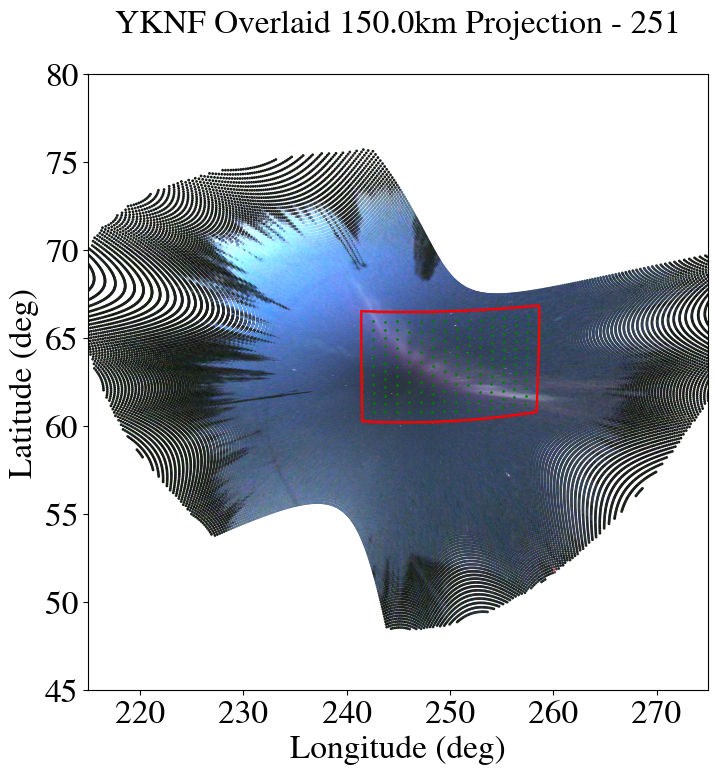


YKNF150000m: len of R_peak_lat_arr:53, len of R_lon_arr:53





In [9]:
GLOBAL_LON_ARR

GLOBAL_LAT_ARR
new_h = 150000

_, peak_lat = fixed_line_interpolate(yknf_lat_proj, yknf_lon_proj, rgb_yknf, 
                                     lat_min_box, lat_max_box, 
                                     lon_min_box, lon_max_box,
                                     lat_cam_yknf, lon_cam_yknf,
                                     "YKNF", time_index, 
                                     og_h, new_h,
                                     GLOBAL_LON_ARR, GLOBAL_LAT_ARR)
# _, peak_lat = altitude_helper.fixed_line_interpolate(fsmi_lat_proj, fsmi_lon_proj, rgb_fsmi, 
#                                      lat_min_box, lat_max_box, 
#                                      lon_min_box, lon_max_box,
#                                      lat_cam_fsmi, lon_cam_fsmi,
#                                      "FSMI", time_index, 
#                                      og_h, new_h,
#                                      GLOBAL_LON_ARR, GLOBAL_LAT_ARR)

In [ ]:
# should be as many elements as there are columns inside the plot above the resampling inside the bounding box 
peak_lat

In [ ]:
lat_cam_fsmi

In [ ]:
lat_cam_yknf

In [ ]:
# def new_compute_metrics_for_altitude(
#     h_target,
#     t_arr,
#     full_azimuth_yknf, full_elevation_yknf, lat_yknf, lon_yknf,
#     full_azimuth_fsmi, full_elevation_fsmi, lat_fsmi, lon_fsmi,
#     yknf_rgb_asi_ds, fsmi_rgb_asi_ds,
#     global_lon_arr, # so same number of longitude slices for all the different projected altitudes
# ):
#     # ---- project ONCE per altitude ----
#     yknf_lat_proj, yknf_lon_proj = new_spherical_project_lat_lon(
#         full_azimuth_yknf, full_elevation_yknf,
#         lat_yknf, lon_yknf, h_target
#     )

#     fsmi_lat_proj, fsmi_lon_proj = new_spherical_project_lat_lon(
#         full_azimuth_fsmi, full_elevation_fsmi,
#         lat_fsmi, lon_fsmi, h_target
#     )

#     #---------Define a single global longitude grid -------------+
#     global_lon_min = int(np.floor(
#         min(np.nanmin(yknf_lon_proj), np.nanmin(fsmi_lon_proj))
#     ))
#     global_lon_max = int(np.ceil(
#         max(np.nanmax(yknf_lon_proj), np.nanmax(fsmi_lon_proj))
#     ))

#     # ---- overlap region (once) ----
#     lat_min = min(np.nanmin(yknf_lat_proj), np.nanmin(fsmi_lat_proj))
#     lon_min = min(np.nanmin(yknf_lon_proj), np.nanmin(fsmi_lon_proj))
#     lat_max = max(np.nanmax(yknf_lat_proj), np.nanmax(fsmi_lat_proj))
#     lon_max = max(np.nanmax(yknf_lon_proj), np.nanmax(fsmi_lon_proj))

#     # fixed auroral box this is based on where the aurora falls for yknf and fsmi relative to our baseline of 150km
#     # will be projecting this entire box up 
#     global_lat_min_box, global_lat_max_box = 60.5, 66
#     global_lon_min_box, global_lon_max_box = 240, 260

#     ssd_vals = [] # sum of squared differences
#     sad_vals = [] # sum of absolute differences
#     avg_diffs = [] # average of absolute differences
#     med_diffs = [] # median of absolute differences 
#     diffs = []

#     yknf_peaks_all = []  # store peak arrays for each time_index
#     fsmi_peaks_all = []
    
#     for time_index in t_arr:
#         # ---- extract RGB frames ----
#         yknf_rgb, fsmi_rgb = mod_plot_lat_lon(
#             yknf_rgb_asi_ds, fsmi_rgb_asi_ds,
#             time_index,
#             "Yellowknife", "Fort Smith",
#             yknf_lat_proj, yknf_lon_proj,
#             fsmi_lat_proj, fsmi_lon_proj,
#             h_target
#         )

#         # ---- interpolate (only need peak arrays) ----
#         _, yknf_peak = fixed_line_interpolate(
#             yknf_lat_proj, yknf_lon_proj, yknf_rgb,
#             lat_min, lat_max, lon_min, lon_max,
#             global_lat_min_box, global_lat_max_box,
#             global_lon_min_box, global_lon_max_box,
#             "yknf", None, time_index, h_target, global_lon_arr
#         )

#         _, fsmi_peak = fixed_line_interpolate(
#             fsmi_lat_proj, fsmi_lon_proj, fsmi_rgb,
#             lat_min, lat_max, lon_min, lon_max,
#             global_lat_min_box, global_lat_max_box,
#             global_lon_min_box, global_lon_max_box,
#             "fsmi", None, time_index, h_target, global_lon_arr
#         )

#         yknf_peaks_all.append(yknf_peak)
#         fsmi_peaks_all.append(fsmi_peak)

#     # convert to arrays 
#     yknf_peaks_all = np.array(yknf_peaks_all)
#     fsmi_peaks_all = np.array(fsmi_peaks_all)

#     global_valid_mask = np.isfinite(yknf_peaks_all) & np.isfinite(fsmi_peaks_all)

#     for t_idx in range(len(t_arr)):
#         diff = yknf_peaks_all[t_idx][global_valid_mask[t_idx]] - fsmi_peaks_all[t_idx][global_valid_mask[t_idx]]
       
#         # ---- Metrics ----
#         ssd_vals.append(np.nansum(np.abs(diff**2)))
#         sad_vals.append(np.nansum(np.abs(diff)))
#         avg_diffs.append(np.mean(np.abs(diff)))
#         med_diffs.append(np.median(np.abs(diff)))
#         diffs.append(np.abs(diff)) # 2d array of the differences for investigation 

#     return h_target, ssd_vals, sad_vals, avg_diffs, med_diffs, diffs

In [14]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
from tqdm import tqdm

ssd_correlation_dict = {}
sad_correlation_dict = {}
avg_correlation_dict = {}
med_correlation_dict = {}
diff_dict = {}

#max_workers = max(1, os.cpu_count() - 4)
max_workers = 4

with ProcessPoolExecutor(max_workers=max_workers) as ex:
    futures = [
        ex.submit(
            altitude_helper.new_compute_metrics_for_altitude,
            og_h, new_h,
            t_arr,
            full_azimuth_yknf, full_elevation_yknf, lat_cam_yknf, lon_cam_yknf,
            full_azimuth_fsmi, full_elevation_fsmi, lat_cam_fsmi, lon_cam_fsmi,
            yknf_rgb_asi_ds, fsmi_rgb_asi_ds,
            GLOBAL_LON_ARR, GLOBAL_LAT_ARR
        )
        for new_h in h_arr
    ]

    for f in tqdm(as_completed(futures), total=len(futures), desc="Computing SSD grid"):
        new_h, ssd_vals, sad_vals, avg_diffs, med_diffs, diffs = f.result()
        ssd_correlation_dict[new_h] = ssd_vals
        sad_correlation_dict[new_h] = sad_vals
        avg_correlation_dict[new_h] = avg_diffs
        med_correlation_dict[new_h] = med_diffs
        diff_dict[new_h] = diffs

Computing SSD grid: 100%|████████████████████| 18/18 [1:43:12<00:00, 344.04s/it]


=====140.0km PROJECTION=======
Total 53 longitudes, and for each of these longitudes have   53 latitudes to interpolate


=====140.0km PROJECTION=======
Total 53 longitudes, and for each of these longitudes have   53 latitudes to interpolate


=====140.0km PROJECTION=======
Total 53 longitudes, and for each of these longitudes have   53 latitudes to interpolate


=====140.0km PROJECTION=======
Total 53 longitudes, and for each of these longitudes have   53 latitudes to interpolate


=====140.0km PROJECTION=======
Total 53 longitudes, and for each of these longitudes have   53 latitudes to interpolate


=====140.0km PROJECTION=======
Total 53 longitudes, and for each of these longitudes have   53 latitudes to interpolate


=====140.0km PROJECTION=======
Total 53 longitudes, and for each of these longitudes have   53 latitudes to interpolate


=====140.0km PROJECTION=======
Total 53 longitudes, and for each of these longitudes have   53 latitudes to interpolate


=====140.0km PROJECTION

### SSD Matrix

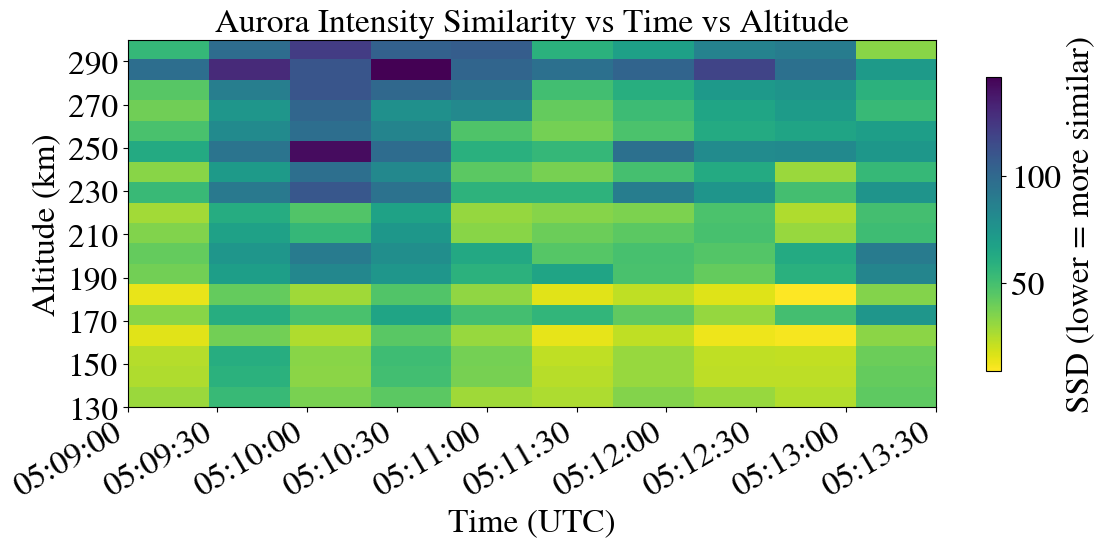

In [15]:
ssd_matrix = np.vstack([ssd_correlation_dict[h] for h in h_arr])

# # prepare altitude + time arrays
# altitude_arr = list(ssd_correlation_dict.keys())
# example_alt = altitude_arr[0]
# #time_arr = np.arange(len(correlation_dict[example_alt]))  # assume same length

# # computer number of altitudes and number of times from ssd_matrix
n_alts, n_times = ssd_matrix.shape

# # generate the time labels for the plot 
t_str_arr = []
for time in t_arr:
    raw_time = yknf_rgb_asi_ds.times.values[time]
    time_obj = pd.to_datetime(raw_time.decode("utf-8").replace(" UTC", ""))
    t_str_arr.append(time_obj.strftime("%H:%M:%S"))

# # plot the correlation matrix over time and projected altitude 
# fig, ax = plt.subplots(figsize=(12, 5))

# im = ax.imshow(
#     ssd_matrix,
#     origin='lower',
#     aspect='auto',
#     extent=[0, n_times - 1, altitude_arr[0], altitude_arr[-1]],
#     cmap='viridis_r'
# )

# cbar = fig.colorbar(im, ax=ax, shrink=0.8)
# cbar.set_label('SSD (lower = more similar)')

# ax.set_xticks(np.arange(n_times))
# ax.set_xticklabels(t_str_arr, rotation=30, ha='right')
# ax.set_ylabel('Altitude (km)')
# ax.set_title('Aurora intensity similarity vs Time vs Altitude')

# plt.tight_layout()
# plt.show()

ssd_matrix = np.vstack([ssd_correlation_dict[h] for h in h_arr])
# 1. Convert your meter-based array to km for cleaner labeling
h_arr_km = [h / 1000 for h in h_arr]

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(
    ssd_matrix,
    origin='lower',
    aspect='auto',
    # Ensure extent matches the km values
    extent=[0, n_times - 1, h_arr_km[0], h_arr_km[-1]], 
    cmap='viridis_r'
)

# --- GRANULAR ALTITUDE LABELS (Every 20km) ---
# Create ticks starting from 150 up to 300, jumping by 20
y_ticks = np.arange(h_arr_km[0], h_arr_km[-1] + 1, 20)
ax.set_yticks(y_ticks)
# ---------------------------------------------

# --- CLEAN TIME LABELS (Subsampling) ---
# Only show ~10-12 time labels to avoid the "black junk" on the X-axis
n_label_step = max(1, n_times // 10) 
indices = np.arange(0, n_times, n_label_step)
selected_labels = [t_str_arr[i] for i in indices]

ax.set_xticks(indices)
ax.set_xticklabels(selected_labels, rotation=30, ha='right')

# Labels and formatting
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('SSD (lower = more similar)')
ax.set_ylabel('Altitude (km)')
ax.set_xlabel('Time (UTC)')
ax.set_title('Aurora Intensity Similarity vs Time vs Altitude')

plt.tight_layout()
plt.show()


In [19]:
ssd_matrix = np.vstack([ssd_correlation_dict[h] for h in h_arr])


In [20]:
ssd_matrix

array([[ 55.95103751,  54.85064804,  65.69728184,  61.53152405,
         60.2333261 ,  50.54716002,  54.57063268,  70.58362598,
         40.80279146,  66.00305577],
       [ 56.88153149,  56.65225774,  70.19981689,  63.00430275,
         61.76753445,  52.63913371,  53.65571249,  73.37195843,
         41.59471999,  67.3972555 ],
       [ 57.54128955,  56.82405908,  73.85929271,  65.77134447,
         63.6795117 ,  55.71915752,  54.39390175,  81.08926418,
         42.75906995,  71.96222633],
       [ 59.07618716,  61.38325251,  76.20318009,  73.56968149,
         69.8610337 ,  58.54612281,  61.79241723,  83.13848397,
         44.60674545,  77.04467536],
       [ 62.22821902,  60.66664102,  82.36401735,  76.65879687,
         71.85137637,  60.55248368,  62.88551366,  86.44097388,
         46.08227674,  78.43065246],
       [ 63.69470676,  57.33912412,  87.170332  ,  81.11976458,
         73.40042073,  63.40152256,  63.25541725,  90.87322885,
         47.64379049,  73.94617857],
       [ 6

In [16]:
ssd_correlation_dict

{170000: [np.float64(57.54128955253748),
  np.float64(56.824059078875116),
  np.float64(73.85929270902828),
  np.float64(65.77134447435056),
  np.float64(63.67951169825418),
  np.float64(55.719157516481204),
  np.float64(54.39390174834836),
  np.float64(81.08926418198371),
  np.float64(42.759069954568936),
  np.float64(71.96222632912325)],
 160000: [np.float64(56.881531490013934),
  np.float64(56.65225773587362),
  np.float64(70.19981688763866),
  np.float64(63.004302752620056),
  np.float64(61.767534451557836),
  np.float64(52.63913371206435),
  np.float64(53.655712489349064),
  np.float64(73.37195842926118),
  np.float64(41.59471999218516),
  np.float64(67.39725549522147)],
 180000: [np.float64(59.07618715622296),
  np.float64(61.38325250505835),
  np.float64(76.20318009025328),
  np.float64(73.56968149149887),
  np.float64(69.86103369565764),
  np.float64(58.54612280814594),
  np.float64(61.79241722839955),
  np.float64(83.13848396694493),
  np.float64(44.60674544995418),
  np.float